# 🌌 OJALA Galaxy Sample Selection and Validation

This notebook builds a **quality-controlled galaxy subcatalogue** from the global OJALA catalogue and produces a set of validation plots.

It includes:

- ✂️ quality cuts
- 📊 diagnostic plots
- 🧪 BPT and WHAN diagrams
- 🖼️ visual inspection of a few galaxy J-PAS photo-spectra
- 💾 export of the final galaxy subcatalogue

## 📦 Imports and plotting style

We load the required packages and set a dark plotting style for consistency with the rest of the OJALA validation notebooks.

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.style.use("dark_background")
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 12,
    "lines.linewidth": 2.5,
    "axes.grid": False,
})

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## ⚙️ User configuration

Edit these paths and thresholds before running the notebook.

The selection of all cuts are defined here in one place.

In [17]:
# ---------------------------------------------------------------------
# USER CONFIGURATION
# ---------------------------------------------------------------------
REPO_ROOT = Path.cwd().resolve()

INPUT_CATALOG = REPO_ROOT / "data" / "catalogues" / "JPAS_EDR_photometry_APER_COR_3_0_OJALA_catalog.csv"
OUTPUT_DIR = REPO_ROOT / "data" / "catalogues"

# Selection cuts
MAG_I_MAX = 21.0
P_GALAXY_MIN = 0.9

MIN_VALID_JPAS_FILTERS = 54

# JPAS photometry prefix used to build the OJALA input features
JPAS_PHOT_PREFIX = "APER_COR_3_0"

# Column names
MAG_I_COL = "MAG_i"
P_GALAXY_COL = "P_GALAXY"
P_STAR_COL = "P_STAR"
CLASS_COL = "CLASS"
Z_GAL_COL = "Z_GAL"
PHOTOZ_COL = "PHOTOZ"

LOGM_COL = "LOGM"
LOGSFR_COL = "LOGSFR"
LOGSFR_HA_COL = "LOGSFR_HA"

HALPHA_EW_COL = "HALPHA_6562_EW"
HBETA_EW_COL = "HBETA_4861_EW"
OIII_EW_COL = "OIII_5007_EW"
NII_EW_COL = "NII_6584_EW"

USE_CLASS_FILTER = True
CLASS_TARGET = "GALAXY"

# Plot settings
FIG_DPI = 180
POINT_SIZE = 10
ALPHA_SCATTER = 0.70
BINS_Z = 60
FIGSIZE = (8, 6)

# Redshift cuts for diagnostic diagrams
MAX_Z_SFR_HA = 0.36
MAX_Z_BPT = 0.36
MAX_Z_WHAN = 0.36

# Visual inspection of random galaxies
N_RANDOM_GALAXY_EXAMPLES = 6
RANDOM_SEED = 42

##  J-PAS filters and effective wavelengths

We define the J-PAS narrow-band filters and their  central wavelengths.

In [18]:
FILTER_JPAS = [
    "J0378", "J0390", "J0400", "J0410", "J0420", "J0430", "J0440", "J0450",
    "J0460", "J0470", "J0480", "J0490", "J0500", "J0510", "J0520", "J0530",
    "J0540", "J0550", "J0560", "J0570", "J0580", "J0590", "J0600", "J0610",
    "J0620", "J0630", "J0640", "J0650", "J0660", "J0670", "J0680", "J0690",
    "J0700", "J0710", "J0720", "J0730", "J0740", "J0750", "J0760", "J0770",
    "J0780", "J0790", "J0800", "J0810", "J0820", "J0830", "J0840", "J0850",
    "J0860", "J0870", "J0880", "J0890", "J0900", "J0910"
]

EFF_WAVE_JPAS = {band: float(band[1:]) for band in FILTER_JPAS}

## 🧰 Helper functions

These functions handle:

- directory creation
- validation of required columns
- quality cuts
- robust plotting limits
- BPT and WHAN sample construction

In [19]:
def ensure_output_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)


def get_jpas_input_columns(prefix):
    return [f"{prefix}_{filt}" for filt in FILTER_JPAS]


def validate_required_columns(df, required_columns):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise ValueError("Missing required columns in the catalogue:\n" + "\n".join(missing))


def count_valid_jpas_filters(df, jpas_columns):
    return df[jpas_columns].notna().sum(axis=1)


def finite_mask(*arrays):
    mask = np.ones(len(arrays[0]), dtype=bool)
    for arr in arrays:
        arr = np.asarray(arr)
        mask &= np.isfinite(arr)
    return mask


def smart_limits(values, pad_frac=0.08, qlow=0.01, qhigh=0.99, fallback=(-1, 1)):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return fallback

    vmin = np.nanquantile(arr, qlow)
    vmax = np.nanquantile(arr, qhigh)

    if not np.isfinite(vmin) or not np.isfinite(vmax):
        return fallback

    if vmax <= vmin:
        delta = 0.5 if vmax == vmin else abs(vmax - vmin)
        return (vmin - delta, vmax + delta)

    pad = pad_frac * (vmax - vmin)
    return (vmin - pad, vmax + pad)

In [20]:
def apply_galaxy_selection(
    df,
    mag_i_col,
    p_galaxy_col,
    z_gal_col,
    jpas_columns,
    mag_i_max,
    p_galaxy_min,
    min_valid_jpas_filters,
    use_class_filter=False,
    class_col=None,
    class_target="GALAXY",
):
    selected = df.copy()

    valid_filter_count = count_valid_jpas_filters(selected, jpas_columns)
    selected["N_VALID_JPAS_FILTERS"] = valid_filter_count

    mask = np.ones(len(selected), dtype=bool)

    mask &= pd.to_numeric(selected[mag_i_col], errors="coerce") < mag_i_max
    # The current selection follows the version you are using now:
    # keep low stellar contamination instead of applying a direct P_GALAXY cut.
    mask &= pd.to_numeric(selected[p_galaxy_col], errors="coerce") >= p_galaxy_min
    mask &= pd.to_numeric(selected["N_VALID_JPAS_FILTERS"], errors="coerce") >= min_valid_jpas_filters
    mask &= pd.to_numeric(selected[z_gal_col], errors="coerce").notna().values

    if use_class_filter and class_col is not None and class_col in selected.columns:
        mask &= selected[class_col].astype(str).values == class_target

    return selected.loc[mask].copy()

## 📈 BPT and WHAN helpers

We use the same BPT/WHAN logic as in the latest validation script.

In [21]:
def kewley01(x):
    return 0.61 / (x - 0.47) + 1.19


def kauffmann03(x):
    return 0.61 / (x - 0.05) + 1.30


def classify_bpt_plot(x, y):
    labels = np.full(len(x), "AGN", dtype=object)

    below_kauff = np.zeros(len(x), dtype=bool)
    below_kewley = np.zeros(len(x), dtype=bool)

    mask_kauff = x < 0.05
    mask_kewley = x < 0.47

    below_kauff[mask_kauff] = y[mask_kauff] < (0.61 / (x[mask_kauff] - 0.05) + 1.30)
    below_kewley[mask_kewley] = y[mask_kewley] < (0.61 / (x[mask_kewley] - 0.47) + 1.19)

    labels[below_kauff & below_kewley] = "Star-forming"
    labels[(~below_kauff) & below_kewley] = "Composite"
    labels[~below_kewley] = "AGN"

    return labels


def build_bpt_sample(df):
    z = pd.to_numeric(df[Z_GAL_COL], errors="coerce").values
    mag_i = pd.to_numeric(df[MAG_I_COL], errors="coerce").values

    nii = pd.to_numeric(df[NII_EW_COL], errors="coerce").values
    ha = pd.to_numeric(df[HALPHA_EW_COL], errors="coerce").values
    oiii = pd.to_numeric(df[OIII_EW_COL], errors="coerce").values
    hb = pd.to_numeric(df[HBETA_EW_COL], errors="coerce").values

    nii_err = pd.to_numeric(df.get(f"{NII_EW_COL}_ERR", np.nan), errors="coerce").values
    ha_err = pd.to_numeric(df.get(f"{HALPHA_EW_COL}_ERR", np.nan), errors="coerce").values
    oiii_err = pd.to_numeric(df.get(f"{OIII_EW_COL}_ERR", np.nan), errors="coerce").values
    hb_err = pd.to_numeric(df.get(f"{HBETA_EW_COL}_ERR", np.nan), errors="coerce").values

    mask = finite_mask(z, mag_i, nii, ha, oiii, hb)
    mask &= mag_i < MAG_I_MAX
    mask &= z < MAX_Z_BPT

    cond_x = ((nii > 10.0) | (ha > 10.0)) & ((nii > 3.0) & (ha > 3.0))
    cond_y = ((oiii > 10.0) | (hb > 10.0)) & ((oiii > 3.0) & (hb > 3.0))
    mask &= cond_x & cond_y

    if np.isfinite(nii_err).any():
        mask &= nii_err < nii
    if np.isfinite(ha_err).any():
        mask &= ha_err < ha
    if np.isfinite(oiii_err).any():
        mask &= oiii_err < oiii
    if np.isfinite(hb_err).any():
        mask &= hb_err < hb

    mask &= (nii > 0.0) & (ha > 0.0) & (oiii > 0.0) & (hb > 0.0)

    sub = df.loc[mask].copy()

    x = np.log10(
        pd.to_numeric(sub[NII_EW_COL], errors="coerce").values
        / pd.to_numeric(sub[HALPHA_EW_COL], errors="coerce").values
    )
    y = np.log10(
        pd.to_numeric(sub[OIII_EW_COL], errors="coerce").values
        / pd.to_numeric(sub[HBETA_EW_COL], errors="coerce").values
    )

    good = np.isfinite(x) & np.isfinite(y)
    sub = sub.loc[good].copy()
    sub["BPT_X"] = x[good]
    sub["BPT_Y"] = y[good]
    sub["BPT_CLASS"] = classify_bpt_plot(sub["BPT_X"].values, sub["BPT_Y"].values)

    return sub


def classify_whan(x, ha_ew):
    labels = np.full(len(x), "Unclassified", dtype=object)

    sf = (x < -0.4) & (ha_ew > 3.0)
    sagn = (x >= -0.4) & (ha_ew > 6.0)
    wagn = (x >= -0.4) & (ha_ew > 3.0) & (ha_ew <= 6.0)
    rg = ha_ew <= 3.0

    labels[sf] = "Star-forming"
    labels[sagn] = "sAGN"
    labels[wagn] = "wAGN"
    labels[rg] = "Retired/passive"

    return labels


def build_whan_sample(df):
    z = pd.to_numeric(df[Z_GAL_COL], errors="coerce").values
    nii = pd.to_numeric(df[NII_EW_COL], errors="coerce").values
    ha = pd.to_numeric(df[HALPHA_EW_COL], errors="coerce").values

    mask = finite_mask(z, nii, ha)
    mask &= z < MAX_Z_WHAN
    mask &= (nii > 0.0) & (ha > 0.0)

    sub = df.loc[mask].copy()

    x = np.log10(
        pd.to_numeric(sub[NII_EW_COL], errors="coerce").values
        / pd.to_numeric(sub[HALPHA_EW_COL], errors="coerce").values
    )
    y = np.log10(pd.to_numeric(sub[HALPHA_EW_COL], errors="coerce").values)

    good = np.isfinite(x) & np.isfinite(y)
    sub = sub.loc[good].copy()
    sub["WHAN_X"] = x[good]
    sub["WHAN_Y"] = y[good]
    sub["WHAN_CLASS"] = classify_whan(sub["WHAN_X"].values, 10 ** sub["WHAN_Y"].values)

    return sub

## 📥 Load the catalogue

We now read the global OJALA catalogue and check that all required columns are present.

In [22]:
ensure_output_dir(OUTPUT_DIR)

print("Reading catalogue...")
df = pd.read_csv(INPUT_CATALOG)

jpas_columns = get_jpas_input_columns(JPAS_PHOT_PREFIX)

required_columns = [
    MAG_I_COL,
    P_GALAXY_COL,
    P_STAR_COL,
    Z_GAL_COL,
    LOGM_COL,
    LOGSFR_COL,
    LOGSFR_HA_COL,
    PHOTOZ_COL,
    HALPHA_EW_COL,
    HBETA_EW_COL,
    OIII_EW_COL,
    NII_EW_COL,
] + jpas_columns

if USE_CLASS_FILTER:
    required_columns.append(CLASS_COL)

validate_required_columns(df, required_columns)

print(f"Number of objects in catalogue: {len(df):,}")
print(f"Number of columns in catalogue: {len(df.columns):,}")

Reading catalogue...
Number of objects in catalogue: 675,672
Number of columns in catalogue: 317


## ✂️ Apply galaxy selection

This creates the science-ready galaxy catalogue.

In [23]:
galaxy_df = apply_galaxy_selection(
    df=df,
    mag_i_col=MAG_I_COL,
    p_galaxy_col=P_GALAXY_COL,
    z_gal_col=Z_GAL_COL,
    jpas_columns=jpas_columns,
    mag_i_max=MAG_I_MAX,
    p_galaxy_min=P_GALAXY_MIN,
    min_valid_jpas_filters=MIN_VALID_JPAS_FILTERS,
    use_class_filter=USE_CLASS_FILTER,
    class_col=CLASS_COL,
    class_target=CLASS_TARGET,
)

print(f"Selected galaxy objects: {len(galaxy_df):,}")
galaxy_df.head()

Selected galaxy objects: 30,523


,TILE_ID,NUMBER,ALPHA_J2000,DELTA_J2000,CLASS_STAR,FWHM_WORLD,KRON_RADIUS,A_WORLD,B_WORLD,R_EFF,...,FLUX_HBETA_ERR,FLUX_OIII5007,FLUX_OIII5007_ERR,FLUX_NII6584,FLUX_NII6584_ERR,HA_HB_RATIO,L_HALPHA_CORR,LOGSFR_HA,LOGSFR_HA_ERR,N_VALID_JPAS_FILTERS
158,9611,38848,245.919218,44.026911,0.029800,0.000389,3.5,0.000184,0.000182,2.969147,...,1.670194e-18,4.587119e-17,9.261826e-18,1.085959e-16,5.469918e-17,1.835738,8.582377e+39,-1.168765,0.096022,54
214,9611,46026,245.922627,43.900167,0.018356,0.000785,3.5,0.000216,0.000211,3.135879,...,5.418091e-17,3.673611e-17,3.547374e-17,7.856321e-17,5.955344e-17,2.622643,3.310404e+41,0.417508,0.971065,54
229,9611,42965,245.923335,43.953467,0.031494,0.000355,3.5,0.000137,0.000124,2.045053,...,2.019505e-18,2.485431e-17,1.751285e-17,2.595346e-17,1.545365e-17,1.210501,5.676365e+39,-1.348303,0.173003,54
268,9611,40323,245.925571,44.000209,0.028625,0.001198,3.5,0.000345,0.000305,4.847155,...,6.866597e-17,1.109440e-16,5.299760e-17,6.316464e-16,2.074366e-16,5.023043,3.336571e+41,0.420927,0.651916,54
301,9611,49051,245.927449,43.849620,0.028625,0.000508,3.5,0.000211,0.000204,3.171996,...,1.510196e-18,2.458198e-17,1.640984e-18,3.271558e-17,1.185007e-17,0.987150,6.921797e+39,-1.262154,0.074901,54


## 🖼️  J-PAS galaxy visualization 


The idea is to inspect a few J-PAS photo-spectra with:

- 🌈 wavelength-based colors
- 📍 redshift annotation
- 💡 key emission lines overplotted when visible

In [24]:
REF_EMISSION_LINES = {
    r"[OII]": 372.709,
    r"H$\beta$": 486.133,
    r"[OIII]": 500.684,
    r"H$\alpha$": 656.280,
}


def plot_panel_jpas_galaxy(ax, row, jpas_columns, ylim=None, prefix=JPAS_PHOT_PREFIX):
    z = row.get(Z_GAL_COL, np.nan)
    mag_i = row.get(MAG_I_COL, np.nan)
    logm = row.get(LOGM_COL, np.nan)
    logsfr = row.get(LOGSFR_COL, np.nan)

    band_names = [col.replace(f"{prefix}_", "") for col in jpas_columns]
    waves = np.array([EFF_WAVE_JPAS[b] for b in band_names], dtype=float)

    vals = []
    errs = []
    for col in jpas_columns:
        vals.append(row.get(col, np.nan))
        errs.append(row.get(f"{col}_ERR", 0.0))

    vals = np.asarray(vals, dtype=float)
    errs = np.asarray(errs, dtype=float)

    valid = np.isfinite(waves) & np.isfinite(vals)

    if valid.sum() == 0:
        ax.text(0.5, 0.5, "No valid J-PAS photometry", ha="center", va="center")
        ax.set_axis_off()
        return

    norm = mcolors.Normalize(vmin=350, vmax=920)
    cmap = plt.get_cmap("turbo")
    colors = cmap(norm(waves))

    for i in range(len(waves)):
        if np.isfinite(vals[i]):
            ax.errorbar(
                waves[i],
                vals[i],
                yerr=errs[i] if np.isfinite(errs[i]) else 0.0,
                fmt="o",
                ecolor=colors[i],
                markerfacecolor=colors[i],
                markeredgecolor="white",
                markeredgewidth=0.5,
                markersize=15,
                elinewidth=1.6,
                zorder=10,
            )

    ax.plot(waves[valid], vals[valid], color="white", alpha=0.35, linewidth=1.4, zorder=2)

    if np.isfinite(z):
        ymin_p, ymax_p = ylim if ylim is not None else (np.nanmin(vals[valid]), np.nanmax(vals[valid]))
        for name, l_rest in REF_EMISSION_LINES.items():
            l_obs = l_rest * (1.0 + z)
            if 350 < l_obs < 920:
                ax.axvline(x=l_obs, color="gray", linestyle="--", linewidth=2.5, 
                           alpha=1, zorder=1)
                y_text = 1.5*ymin_p 
                ax.text(
                    l_obs, y_text, name, rotation=90, color="white", fontsize=15,
                    va="center", ha="center", backgroundcolor="black", alpha=1
                )

    
    fontsize1= 20
    ax.text(0.04, 0.92, "GALAXY", transform=ax.transAxes, color="white", fontweight="bold", 
            fontsize=fontsize1)
    ax.text(0.04, 0.82, f"z = {z:.3f}" if np.isfinite(z) else "z = nan", 
            transform=ax.transAxes, fontsize=fontsize1)
    ax.text(0.54, 0.92, f"$i$ = {mag_i:.2f}" if np.isfinite(mag_i) else "$i$ = nan",
            transform=ax.transAxes, fontsize=fontsize1)
    ax.text(0.54, 0.82, f"logM = {logm:.2f}" if np.isfinite(logm) else "logM = nan", 
            transform=ax.transAxes, fontsize=fontsize1)
    ax.text(0.04, 0.72, f"logSFR = {logsfr:.2f}" if np.isfinite(logsfr) else "logSFR = nan",
            transform=ax.transAxes, fontsize=fontsize1)

    ax.set_xlim(350, 920)
    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.set_xlabel(r"$\lambda$ [nm]",fontsize = fontsize1)
    ax.set_ylabel("Normalized Flux",fontsize = fontsize1)
    ax.grid(False)

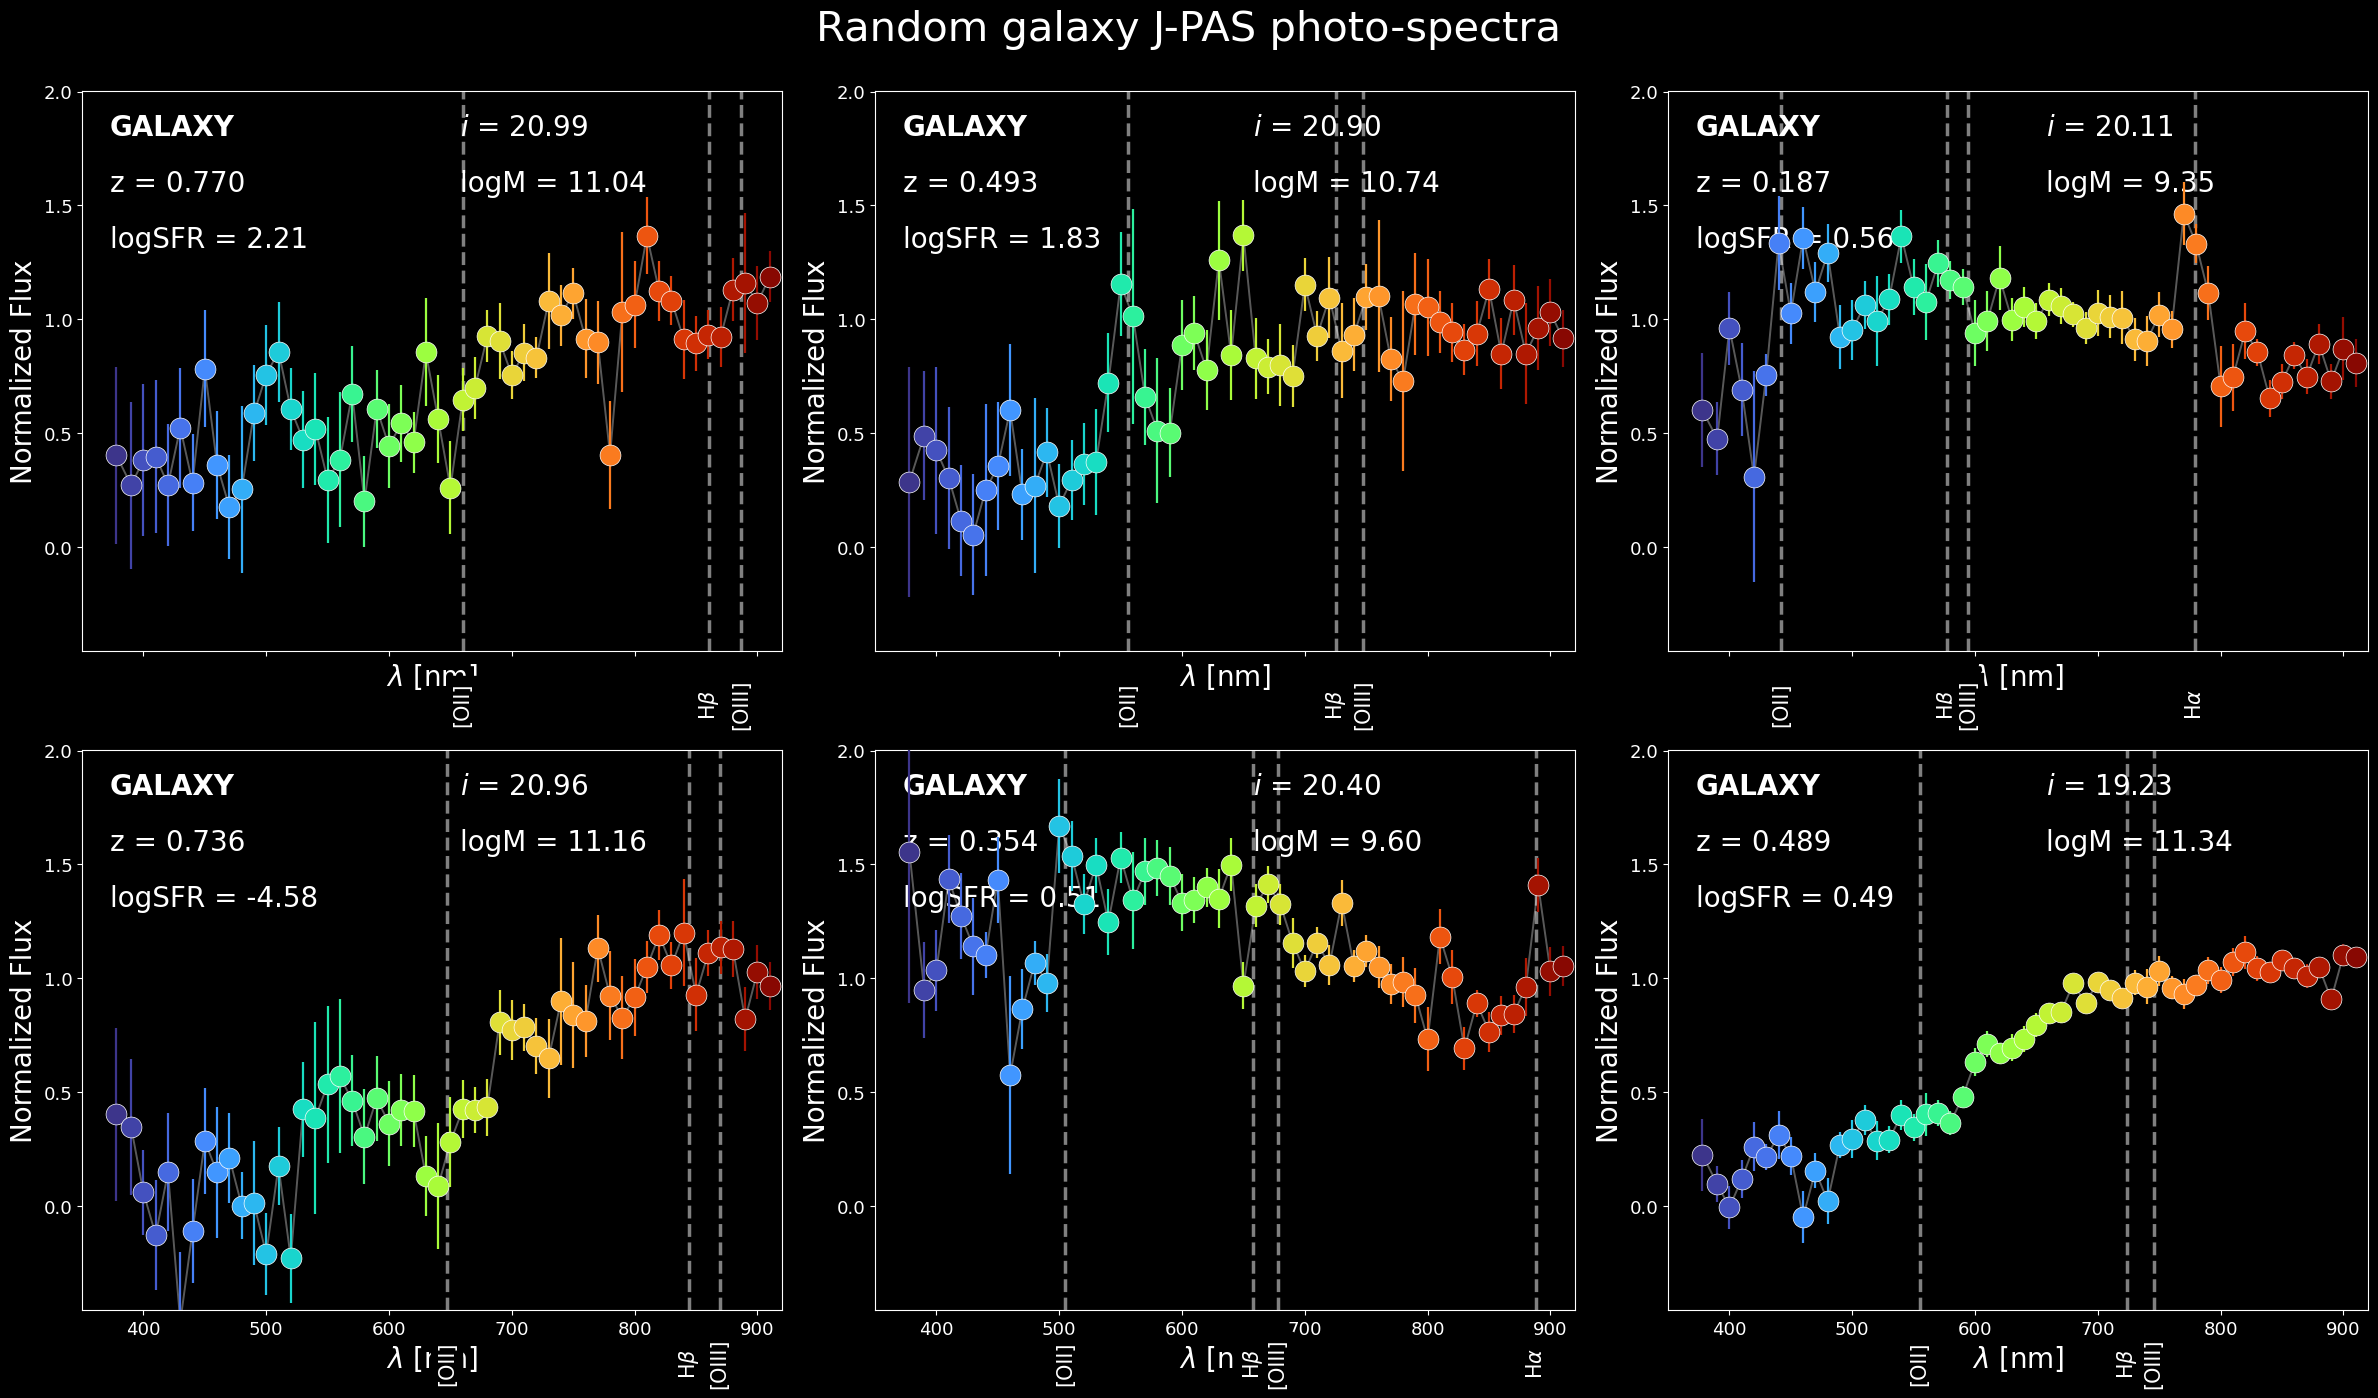

In [25]:

n_examples = min(N_RANDOM_GALAXY_EXAMPLES, len(galaxy_df))
plot_df = galaxy_df.sample(n=n_examples, random_state=2).copy()

ncols = 3
nrows = int(np.ceil(n_examples / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(24, 7 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()

for i, ax in enumerate(axes):
    if i >= len(plot_df):
        ax.set_axis_off()
        continue

    row = plot_df.iloc[i]

    # Compute common y-limits from the selected sample for cleaner comparison
    row_data = plot_df[jpas_columns].values.flatten()
    row_data = row_data[np.isfinite(row_data)]
    ylim = (np.min(row_data) * 0.9, np.max(row_data) * 1.2) if len(row_data) > 0 else None

    plot_panel_jpas_galaxy(
        ax=ax,
        row=row,
        jpas_columns=jpas_columns,
        ylim=ylim,
        prefix=JPAS_PHOT_PREFIX,
    )

fig.suptitle("Random galaxy J-PAS photo-spectra", fontsize=30, y=0.995)
plt.tight_layout()
plt.show()

## 📊 LOGSFR vs LOGM

A first sanity check of the selected galaxy sample.

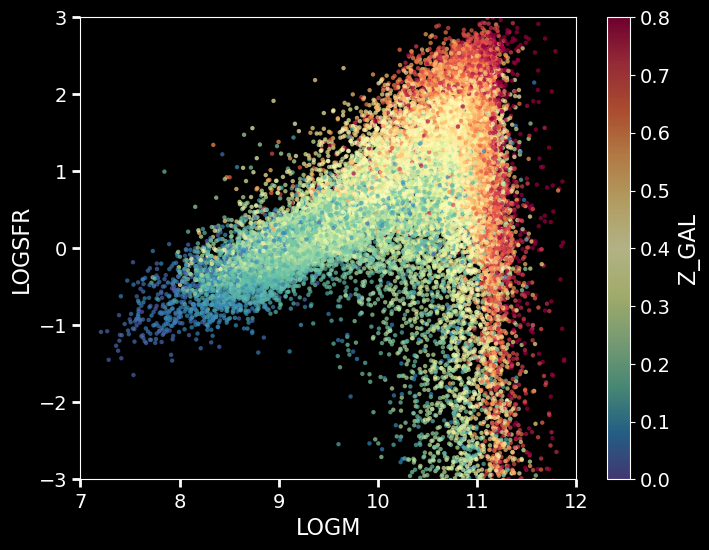

In [26]:
x = pd.to_numeric(galaxy_df[LOGM_COL], errors="coerce").values
y = pd.to_numeric(galaxy_df[LOGSFR_COL], errors="coerce").values
z = pd.to_numeric(galaxy_df[Z_GAL_COL], errors="coerce").values

mask = finite_mask(x, y, z)
#mask = mask & (galaxy_df[Z_GAL_COL] < 0.35)


fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(
    x[mask], y[mask],
    c=z[mask],
    cmap="Spectral_r",
    s=POINT_SIZE,
    alpha=ALPHA_SCATTER,
    edgecolors="none",
    linewidths=2, # Increased line width
    vmin=0,
    vmax=0.8
)

# Configure colorbar with larger labels
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Z_GAL", fontsize=16)
cbar.ax.tick_params(labelsize=14)

ax.set_xlim(*smart_limits(x[mask], fallback=(7.5, 12.5)))
ax.set_ylim(*smart_limits(y[mask], fallback=(-4.0, 3.0)))
ax.set_ylim(-3.0, 3.0)
ax.set_xlim(7, 12.0)
# Larger labels and ticks
ax.set_xlabel("LOGM", fontsize=16)
ax.set_ylabel("LOGSFR", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14, width=2, length=6)

# Removed grid as requested
ax.grid(False)

plt.show()

## 📊 LOGSFR_HA vs LOGM for low-redshift galaxies

This is restricted to `Z_GAL < 0.35`.

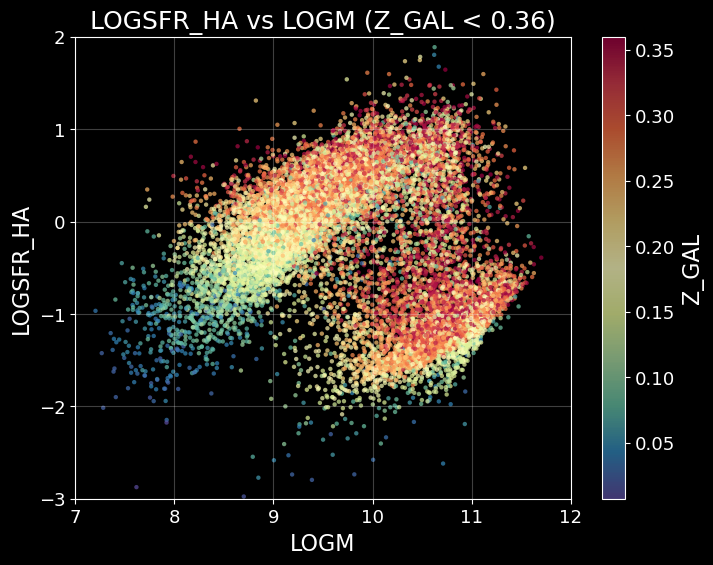

In [27]:
x = pd.to_numeric(galaxy_df[LOGM_COL], errors="coerce").values
y = pd.to_numeric(galaxy_df[LOGSFR_HA_COL], errors="coerce").values
z = pd.to_numeric(galaxy_df[Z_GAL_COL], errors="coerce").values

mask = finite_mask(x, y, z)
mask &= z < MAX_Z_SFR_HA

fig, ax = plt.subplots(figsize=FIGSIZE)
sc = ax.scatter(
    x[mask], y[mask],
    c=z[mask],
    cmap="Spectral_r",
    s=POINT_SIZE,
    alpha=ALPHA_SCATTER,
    edgecolors="none",
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Z_GAL")

ax.set_ylim(-3.0, 2.0)
ax.set_xlim(7, 12.0)

ax.set_xlabel("LOGM")
ax.set_ylabel("LOGSFR_HA")
ax.set_title(f"LOGSFR_HA vs LOGM (Z_GAL < {MAX_Z_SFR_HA})")
ax.grid(True, alpha=0.25)
plt.show()

## 📚 Redshift comparison: OJALA vs LePHARE

This compares the OJALA galaxy redshift prediction with LePHARE photo-z available in the catalogue.

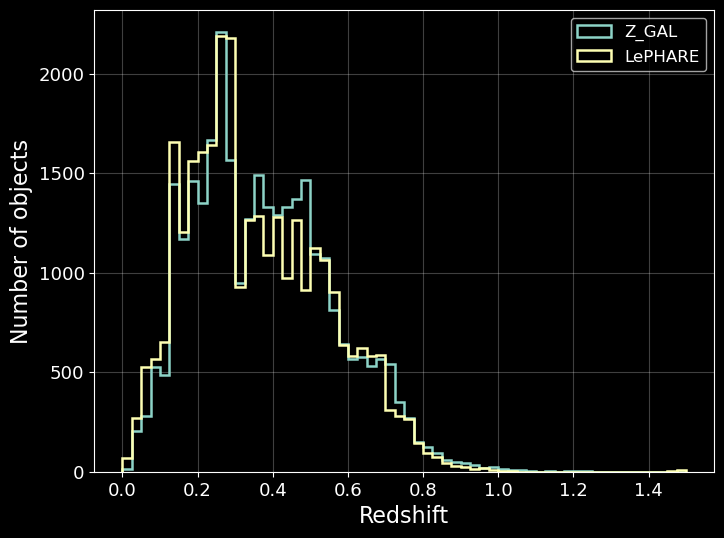

In [28]:
z_gal = pd.to_numeric(galaxy_df[Z_GAL_COL], errors="coerce").values
photoz = pd.to_numeric(galaxy_df[PHOTOZ_COL], errors="coerce").values

mask_zgal = np.isfinite(z_gal)
mask_photoz = np.isfinite(photoz)

zmin = min(np.nanmin(z_gal[mask_zgal]), np.nanmin(photoz[mask_photoz]))
zmax = max(np.nanmax(z_gal[mask_zgal]), np.nanmax(photoz[mask_photoz]))
bins = np.linspace(zmin, zmax, BINS_Z + 1)

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(z_gal[mask_zgal], bins=bins, histtype="step", linewidth=1.8, label="Z_GAL")
ax.hist(photoz[mask_photoz], bins=bins, histtype="step", linewidth=1.8, label='LePHARE')

ax.set_xlabel("Redshift")
ax.set_ylabel("Number of objects")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

## 🧪 BPT Diagram

We impose a minimum equivalent width of **EW > 3 Å**.  
Note that AGN-dominated galaxies are excluded by applying the condition **P_GAL > 0.9**.

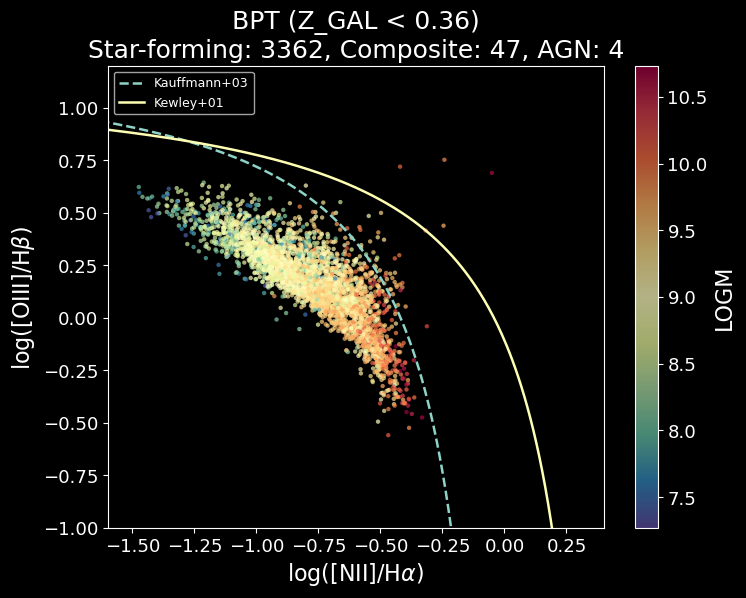

In [29]:
bpt_df = build_bpt_sample(galaxy_df)

fig, ax = plt.subplots(figsize=FIGSIZE)

if len(bpt_df) == 0:
    ax.text(0.5, 0.5, "No objects satisfy the BPT selection.", ha="center", va="center")
    ax.set_axis_off()
else:
    x = pd.to_numeric(bpt_df["BPT_X"], errors="coerce").values
    y = pd.to_numeric(bpt_df["BPT_Y"], errors="coerce").values
    logm = pd.to_numeric(bpt_df[LOGM_COL], errors="coerce").values

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(logm)
    x = x[mask]
    y = y[mask]
    logm = logm[mask]
    sub_plot = bpt_df.loc[mask].copy()

    sc = ax.scatter(
        x, y,
        c=logm,
        cmap="Spectral_r",
        s=POINT_SIZE,
        alpha=ALPHA_SCATTER,
        edgecolors="none",
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("LOGM")

    xgrid = np.linspace(-2.0, 1.0, 500)
    x_kauff = xgrid[xgrid < 0.05]
    y_kauff = 0.61 / (x_kauff - 0.05) + 1.3
    x_kewley = xgrid[xgrid < 0.47]
    y_kewley = 0.61 / (x_kewley - 0.47) + 1.19

    ax.plot(x_kauff, y_kauff, linestyle="--", linewidth=1.8, label="Kauffmann+03")
    ax.plot(x_kewley, y_kewley, linestyle="-", linewidth=1.8, label="Kewley+01")

    counts = sub_plot["BPT_CLASS"].value_counts()
    n_sf = counts.get("Star-forming", 0)
    n_comp = counts.get("Composite", 0)
    n_agn = counts.get("AGN", 0)

    ax.set_xlim(-1.6, 0.4)
    ax.set_ylim(-1.0, 1.2)
    ax.set_xlabel(r"log([NII]/H$\alpha$)")
    ax.set_ylabel(r"log([OIII]/H$\beta$) ")
    ax.set_title(
        f"BPT (Z_GAL < {MAX_Z_BPT})\n"
        f"Star-forming: {n_sf}, Composite: {n_comp}, AGN: {n_agn}"
    )
    ax.grid(False)
    ax.legend(loc="upper left", fontsize=9)

plt.show()

## 🧪 WHAN diagram

This is a complementary low-redshift diagnostic based on `[NII]/Hα` and `EW(Hα)`.

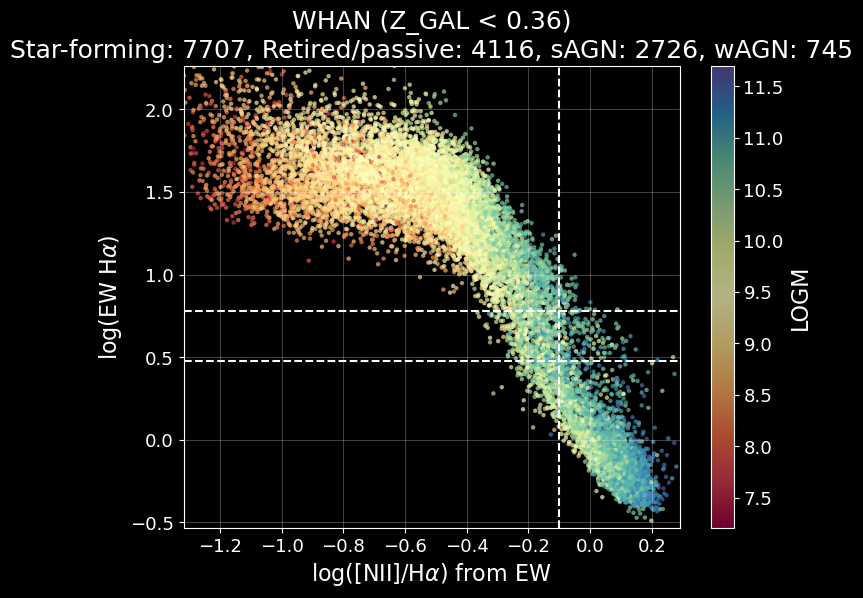

In [30]:
whan_df = build_whan_sample(galaxy_df)

fig, ax = plt.subplots(figsize=FIGSIZE)

if len(whan_df) == 0:
    ax.text(0.5, 0.5, "No objects satisfy the WHAN selection.", ha="center", va="center")
    ax.set_axis_off()
else:
    x = pd.to_numeric(whan_df["WHAN_X"], errors="coerce").values
    y = pd.to_numeric(whan_df["WHAN_Y"], errors="coerce").values
    logm = pd.to_numeric(whan_df[LOGM_COL], errors="coerce").values

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(logm)
    mask &= (x > -1.6) & (x < 0.5)
    mask &= (y > -1.0) & (y < 2.5)

    x = x[mask]
    y = y[mask]
    logm = logm[mask]
    sub_plot = whan_df.loc[mask].copy()

    sc = ax.scatter(
        x, y,
        c=logm,
        cmap="Spectral",
        s=POINT_SIZE,
        alpha=ALPHA_SCATTER,
        edgecolors="none",
    )
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("LOGM")

    #Ke01 Line
    ax.axvline(-0.1, linewidth=1.5, linestyle="--")
    ax.axhline(np.log10(3.0), linewidth=1.5, linestyle="--")
    ax.axhline(np.log10(6.0), linewidth=1.5, linestyle="--")

    counts = sub_plot["WHAN_CLASS"].value_counts()
    subtitle = ", ".join([f"{k}: {v}" for k, v in counts.items()])

    xlim = smart_limits(x, pad_frac=0.08, qlow=0.01, qhigh=0.99, fallback=(-1.5, 0.4))
    ylim = smart_limits(y, pad_frac=0.08, qlow=0.01, qhigh=0.99, fallback=(-0.8, 2.3))

    xlim = (max(xlim[0], -1.6), min(xlim[1], 0.5))
    ylim = (max(ylim[0], -1.0), min(ylim[1], 2.5))

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"log([NII]/H$\alpha$) from EW")
    ax.set_ylabel(r"log(EW H$\alpha$)")
    ax.set_title(f"WHAN (Z_GAL < {MAX_Z_WHAN})\n{subtitle}")
    ax.grid(True, alpha=0.25)

plt.show()

## 💾 Save the galaxy catalogue



In [25]:
output_subcatalog = OUTPUT_DIR / "galaxy_catalog.csv"
galaxy_df.to_csv(output_subcatalog, index=False)
print(f"Saved: {output_subcatalog}")

Saved: /Users/ginesmartinezsolaeche/Galaxies/OJALA_pipeline/data/catalogues/galaxy_catalog.csv
